<a href="https://colab.research.google.com/github/NehaSontakk/KEGG_GRAPH/blob/main/KO_graph_generation_from_expression_w_source_sink.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this script

1.   Load a KO Expression from the API
2.   Generate a graph from it
3.   Create a node list, adjacency list for original graph
4.   Store this graph object/ adjacency list



In [1]:
!pip install bioservices
!apt-get install graphviz libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 21 not upgraded.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from bioservices import KEGG
import re
import pandas as pd
import sys


In [3]:
graph_storage_directory = "/content/drive/MyDrive/Lab Work/KEGG_KO_Graphs/KEGG_Graph_Storage/"

In [4]:
#Gather KO definitions
def fetch_and_plot_reactions(module_id):
    kegg = KEGG()
    try:
        module_info = kegg.get(module_id)
        print(module_info)
        module_parsed = kegg.parse(module_info)
        print(module_parsed)
    except Exception as e:
        print(f"Failed to retrieve or parse module: {e}")
        return None

    reactions = module_parsed.get("REACTION", {})
    orthology = module_parsed.get("ORTHOLOGY", {})
    compounds = module_parsed.get("COMPOUND",{})
    definition = module_parsed.get("DEFINITION",{})
    if not reactions:
        print("No reactions found in the module.")
        return None

    return reactions,orthology,compounds,definition

#reactions,orthology,compounds,definition = fetch_and_plot_reactions(module_id)
#fetch_and_plot_reactions(module_id)

In [5]:
#Building the node class
class Node:
    node_counter = 1  # Class variable for unique node IDs

    def __init__(self, name):
        self.name = name
        self.id = Node.node_counter
        Node.node_counter += 1
        self.visited = False
        self.children = []

    def __repr__(self):
        return f"{self.id}_{self.name}"

    # Implement equality and hashing based on the unique id
    def __eq__(self, other):
        return isinstance(other, Node) and self.id == other.id

    def __hash__(self):
        return hash(self.id)



In [6]:
# Global variables
nodes = []   # List of all Node objects
edges = []   # List of edges as tuples (from_node, to_node)
tokens = []
current_token_index = 0
indent_level = 0  # For tracking indentation in print statements

In [7]:
#Helper functions to create nodes and edges
def create_node(name):
    node = Node(name)
    nodes.append(node)
    return node

def create_edges(from_nodes, to_nodes):
    for from_node in from_nodes:
        for to_node in to_nodes:
            if from_node != to_node and (from_node, to_node) not in edges:
                edges.append((from_node, to_node))
                print(f"Added edge: {from_node} -> {to_node}")

In [8]:
#Tokenizing function for the input
def tokenize(input_string):
    tokens = []
    i = 0
    input_string = input_string.replace("-- ", "")
    while i < len(input_string):
        c = input_string[i]
        if c.isalnum():
            start = i
            while i < len(input_string) and input_string[i].isalnum():
                i += 1
            tokens.append(input_string[start:i])
        elif c in "-+,() ":
            tokens.append(c)
            i += 1
        else:
            i += 1
    return tokens

In [9]:
#Helper functions
def current_token():
    if current_token_index < len(tokens):
        return tokens[current_token_index]
    else:
        return None

def match(token_value):
    global current_token_index
    if current_token() == token_value:
        current_token_index += 1
        return True
    else:
        return False

def expect(token_value):
    if match(token_value):
        return True
    else:
        raise Exception(f"Expected '{token_value}' but found '{current_token()}'")

def consume_token():
    global current_token_index
    current_token_index += 1

In [10]:
#Recursive parsing functions
def parse_expr():
    #Step 1
    #Gather all the space seperated steps in the expression
    global indent_level
    print('  ' * indent_level + f'Entering parse_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_sum_expr()
    while match(" "):
        print('  ' * indent_level + f'Matched space, current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_sum_expr()
        create_edges(last_nodes, next_top_nodes)
        print('  ' * indent_level + f'Created edges from {last_nodes} to {next_top_nodes}')
        last_nodes = next_last_nodes
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_sum_expr():
    #Step 2
    #Gather all the comma seperated steps in the expression
    global indent_level
    print('  ' * indent_level + f'Entering parse_sum_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_mult_expr()
    while match(","):
        print('  ' * indent_level + f'Matched ",", current token: {current_token()}')
        next_top_nodes, next_last_nodes = parse_mult_expr()
        top_nodes.extend(next_top_nodes)
        last_nodes.extend(next_last_nodes)
        print('  ' * indent_level + f'Combined top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_sum_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_mult_expr():
    #Step 3
    #Gather all the + or - operations and process seperately
    global indent_level
    print('  ' * indent_level + f'Entering parse_mult_expr at token: {current_token()}')
    indent_level += 1
    top_nodes, last_nodes = parse_factor()

    # Initialize chain_nodes with last_nodes
    chain_nodes = last_nodes.copy()

    while True:
        operator = None
        if match("+"):
            operator = "+"
        elif match("-"):
            operator = "-"
        else:
            break  # Exit loop if neither "+" nor "-" matches

        print('  ' * indent_level + f'Matched "{operator}", current token: {current_token()}')

        # Parse the next expression
        next_top_nodes, next_last_nodes = parse_mult_expr()

        if operator == "+":
            # "+" operator implies a direct sequence
            create_edges(last_nodes, next_top_nodes)
            print(f'Created sequential edges from {last_nodes} to {next_top_nodes}')
            # Update last_nodes
            last_nodes = next_last_nodes
            # Reset chain_nodes to last_nodes
            chain_nodes = last_nodes.copy()
        elif operator == "-":
            # "-" operator implies branching
            # Create branching edges from all nodes in chain_nodes to next_top_nodes
            create_edges(chain_nodes, next_top_nodes)
            print(f'Created branching edges from {chain_nodes} to {next_top_nodes}')
            # Create additional branching edges from last_nodes to next_top_nodes
            create_edges(last_nodes, next_top_nodes)
            print(f'Created additional branching edges from {last_nodes} to {next_top_nodes}')
            # Accumulate chain_nodes with next_last_nodes
            chain_nodes.extend(next_last_nodes)
            # Update last_nodes
            last_nodes = next_last_nodes

    # After loop, connect each node in chain_nodes to all nodes after it
    if chain_nodes and len(chain_nodes) > 1:
        for i in range(len(chain_nodes)):
            from_node = chain_nodes[i]
            targets = chain_nodes[i+1:]
            create_edges([from_node], targets)
            print(f'Created edges from {from_node} to {targets}')

    # Set last_nodes to chain_nodes to include all chain nodes
    last_nodes = chain_nodes.copy()

    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_mult_expr with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

def parse_factor():
    #Step 4
    #Fianl step to process the alphanumeric nodes
    global indent_level
    print('  ' * indent_level + f'Entering parse_factor at token: {current_token()}')
    indent_level += 1
    if match("("):
        print('  ' * indent_level + f'Matched "(", current token: {current_token()}')
        top_nodes, last_nodes = parse_expr()
        expect(")")
        print('  ' * indent_level + f'Expecting ")", current token: {current_token()}')
    elif current_token() is not None and current_token()[0].isalnum():
        token_name = current_token()
        print('  ' * indent_level + f'Creating node for token: {token_name}')
        consume_token()
        node = create_node(token_name)
        top_nodes = [node]
        last_nodes = [node]
    else:
        raise Exception(f"Unexpected token: {current_token()}")
    indent_level -= 1
    print('  ' * indent_level + f'Exiting parse_factor with top_nodes: {top_nodes}, last_nodes: {last_nodes}')
    return top_nodes, last_nodes

In [11]:
def get_source_proteins(reactions, orthology):
    print("Getting source proteins.")
    if not reactions:
        raise ValueError("No reactions returned.")

    # Process the first reaction to extract source compounds (left-hand side)
    first_key = list(reactions.keys())[0]
    print("First key:", first_key)
    first_reaction = reactions.get(first_key)
    print("First reaction:", first_reaction)
    source_compounds = []
    if first_reaction and "->" in first_reaction:
        left_side = first_reaction.split("->")[0]
        if "+" in left_side:
            # Multiple source compounds
            source_compounds = [compound.strip() for compound in left_side.split("+")]
        else:
            # Single source compound
            source_compounds = [left_side.strip()]
    else:
        print("Warning: The first reaction is missing a '->' delimiter or is empty. No source compounds detected.")

    # Find all reaction keys that include any of the source compounds
    source_reaction_keys = set()
    for key, reaction_str in reactions.items():
        for compound in source_compounds:
            if compound in reaction_str:
                source_reaction_keys.add(key)

    print("Combined reaction keys:", source_reaction_keys)

    # Expand comma-separated reaction keys into individual reaction IDs
    individual_reaction_ids = set()
    for key in source_reaction_keys:
        for reaction_id in key.split(","):
            individual_reaction_ids.add(reaction_id.strip())

    print("Individual reaction IDs:", individual_reaction_ids)

    # Now find all KOs (proteins) that are associated with these individual reaction IDs.
    # If the KO string contains commas, split it and add each KO individually.
    source_proteins = set()
    for ko, reaction_list in orthology.items():
        print("Orthology reaction list for KO(s):", reaction_list)
        for reaction_id in individual_reaction_ids:
            if reaction_id in reaction_list:
                for single_ko in ko.split(","):
                    source_proteins.add(single_ko.strip())

    return source_proteins




def get_sink_proteins(reactions, orthology):
    print("Getting Sink proteins.")
    if not reactions:
        raise ValueError("No reactions returned.")

    # Process the last reaction to extract the sink compound (right-hand side)
    last_key = list(reactions.keys())[-1]
    last_reaction = reactions.get(last_key)
    sink_compound = None
    if last_reaction and "->" in last_reaction:
        right_side = last_reaction.split("->")[1]
        if "+" in right_side:
            # Multiple compounds on the target side; take the last one
            compounds_list = [compound.strip() for compound in right_side.split("+")]
            sink_compound = compounds_list[-1]
        else:
            sink_compound = right_side.strip()
    else:
        print("Warning: The last reaction is missing a '->' delimiter or is empty. No sink compound detected.")

    # Find all reaction keys that include the sink compound
    sink_reaction_keys = set()
    if sink_compound:
        for key, reaction_str in reactions.items():
            if sink_compound in reaction_str:
                sink_reaction_keys.add(key)
    print("Combined sink reaction keys:", sink_reaction_keys)

    # Expand comma-separated reaction keys into individual reaction IDs
    individual_reaction_ids = set()
    for key in sink_reaction_keys:
        for reaction_id in key.split(","):
            individual_reaction_ids.add(reaction_id.strip())
    print("Individual sink reaction IDs:", individual_reaction_ids)

    # Now find all KOs (proteins) associated with these individual reaction IDs.
    # If the KO string contains commas, split it and add each KO individually.
    sink_proteins = set()
    for ko, reaction_list in orthology.items():
        for reaction_id in individual_reaction_ids:
            if reaction_id in reaction_list:
                for single_ko in ko.split(","):
                    sink_proteins.add(single_ko.strip())

    return sink_proteins


# Example usage:
#if __name__ == "__main__":
#    reaction_id = "M00002"
#    reactions, orthology, compounds, definition = fetch_and_plot_reactions(reaction_id)
#    source_KOs = get_source_proteins(reactions, orthology)
#    print("Source proteins (KOs):", source_KOs)

#    sink_KOs = get_sink_proteins(reactions, orthology)
#    print("Sink proteins (KOs):", sink_KOs)


In [12]:
#Function to build the actual graph
#Add source and sink nodes

def generate_graph(nodes, edges):
    G = nx.DiGraph()
    for node in nodes:
        G.add_node(str(node))
    for edge in edges:
        if len(edge) == 3:
            from_node, to_node, label = edge
            G.add_edge(str(from_node), str(to_node), label=label)
        else:
            from_node, to_node = edge
            G.add_edge(str(from_node), str(to_node))
    return G

def build_graph(input_string, reactions, orthology):
    global tokens, current_token_index, nodes, edges, indent_level
    # Tokenize and parse the input to build the basic graph structure.
    tokens = tokenize(input_string)
    current_token_index = 0
    nodes = []
    edges = []
    indent_level = 0
    parse_expr()

    # Get source and sink proteins from the reaction_id using our helper functions.
    source_proteins_set = get_source_proteins(reactions, orthology)
    sink_proteins_set = get_sink_proteins(reactions, orthology)

    print("HERE!")
    print("Source proteins:", source_proteins_set)
    print("Sink proteins:", sink_proteins_set)

    # --- Create dedicated "Source" and "Sink" nodes ---
    source_node = Node("Source")
    sink_node = Node("Sink")
    nodes.append(source_node)
    nodes.append(sink_node)

    # --- Match existing graph nodes to the source/sink protein sets ---
    # Look for nodes whose names contain any of the KO strings.
    matched_source_nodes = []
    matched_sink_nodes = []
    for node in nodes:
        # Skip the dedicated Source/Sink nodes
        if node.name in ["Source", "Sink"]:
            continue
        # For source matching:
        for ko in source_proteins_set:
            if ko in node.name:
                matched_source_nodes.append(node)
                break  # Found a match for this node; move on.
        # For sink matching:
        for ko in sink_proteins_set:
            if ko in node.name:
                matched_sink_nodes.append(node)
                break

    # --- Add edges from the dedicated Source node to each matched source node ---
    for mnode in matched_source_nodes:
        edges.append((source_node, mnode))

    # --- Add edges from each matched sink node to the dedicated Sink node ---
    for mnode in matched_sink_nodes:
        edges.append((mnode, sink_node))

    # --- Continue with the rest of your graph processing ---
    # Build dictionaries to count incoming and outgoing edges for each node.
    node_incoming = {node: 0 for node in nodes}
    node_outgoing = {node: 0 for node in nodes}
    for from_node, to_node in edges:
        node_incoming[to_node] = node_incoming.get(to_node, 0) + 1
        node_outgoing[from_node] = node_outgoing.get(from_node, 0) + 1

    # For every node (except the dedicated Source/Sink), if it has no incoming edges, add an edge from Source.
    for node in nodes:
        if node.name not in ["Source", "Sink"]:
            if node_incoming.get(node, 0) == 0:
                edges.append((source_node, node))
    # For every node (except the dedicated Source/Sink), if it has no outgoing edges, add an edge to Sink.
    for node in nodes:
        if node.name not in ["Source", "Sink"]:
            if node_outgoing.get(node, 0) == 0:
                edges.append((node, sink_node))

    return nodes, edges



In [13]:
#Represent
def visualize_graph(G,module_id):
    pos = nx.nx_pydot.graphviz_layout(G, prog='dot')

    plt.figure(figsize=(12,12))
    nx.draw(G, pos, with_labels=True, node_size=400, node_color='lightblue', arrows=True, arrowstyle='->', arrowsize=20)

    # Draw edge labels if any
    edge_labels = nx.get_edge_attributes(G, 'label')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Directed Graph of Module "+str(module_id))
    plt.axis('off')
    plt.show()

In [14]:
import os
import json
import pickle

def save_graph_and_adjacency_list(G, module_id, storage_directory="graph_storage/"):
    # Create the directory if it doesn't exist
    if not os.path.exists(storage_directory):
        os.makedirs(storage_directory)

    # Define file paths
    graph_path = f"{storage_directory}{module_id}_graph.pkl"
    adjacency_list_path = f"{storage_directory}{module_id}_adjacency_list.json"

    # Check if files already exist
    if os.path.exists(graph_path) and os.path.exists(adjacency_list_path):
        print(f"Files for module {module_id} already exist. Skipping save.")
        return

    # Save the graph object as a pickle file
    with open(graph_path, "wb") as f:
        pickle.dump(G, f)

    # Save the adjacency list as JSON
    adjacency_list = nx.to_dict_of_lists(G)
    with open(adjacency_list_path, "w") as f:
        json.dump(adjacency_list, f)

    print(f"Graph and adjacency list for {module_id} saved in {storage_directory}")



Enter the module IDs separated by commas: M00345
Received module IDs: ['M00345']

Processing module: M00345
ENTRY       M00345            Pathway   Module
NAME        Formaldehyde assimilation, ribulose monophosphate pathway
DEFINITION  (((K08093,K13812) K08094),K13831) (K00850,K16370,K21071) K01624
ORTHOLOGY   K08093,K13812,K13831  3-hexulose-6-phosphate synthase [EC:4.1.2.43] [RN:R05338]
            K08094,K13831  6-phospho-3-hexuloisomerase [EC:5.3.1.27] [RN:R05339]
            K00850,K16370,K21071  6-phosphofructokinase [EC:2.7.1.11] [RN:R00756]
            K01624  fructose-bisphosphate aldolase, class II [EC:4.1.2.13] [RN:R01068]
CLASS       Pathway modules; Energy metabolism; Methane metabolism
PATHWAY     map00030  Pentose phosphate pathway
            map00680  Methane metabolism
            map01200  Carbon metabolism
            map01230  Biosynthesis of amino acids
            map01100  Metabolic pathways
            map01120  Microbial metabolism in diverse environments
REA

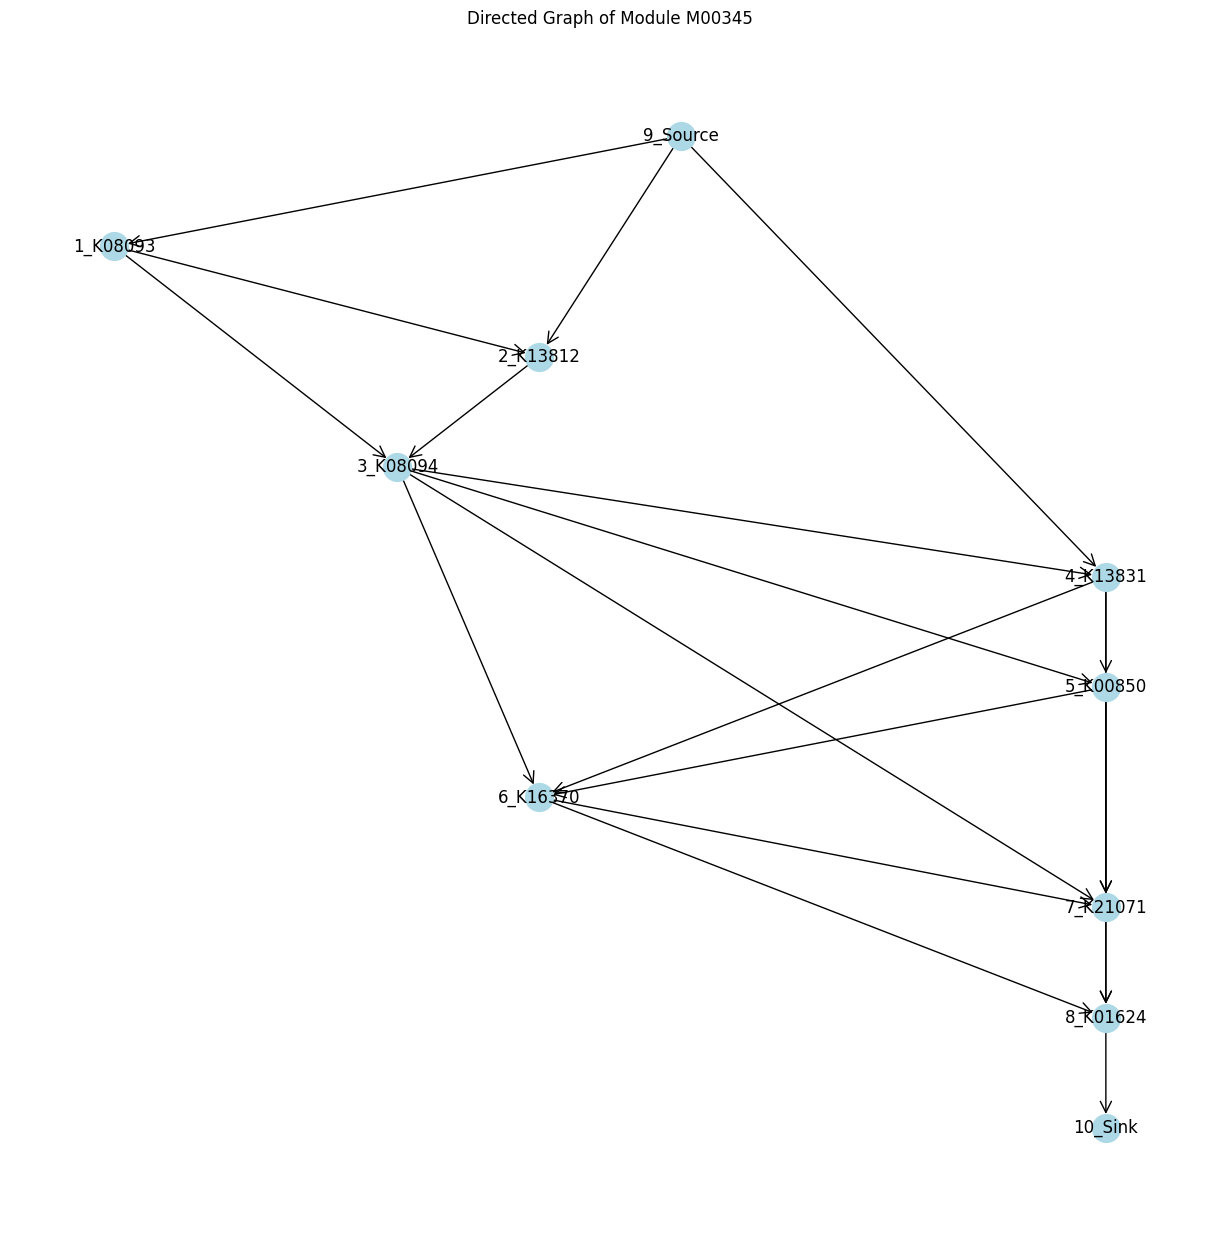

Graph and adjacency list for M00345 saved in /content/drive/MyDrive/Lab Work/KEGG_KO_Graphs/KEGG_Graph_Storage/
Graph and adjacency list saved.

Graph Nodes: ['1_K08093', '2_K13812', '3_K08094', '4_K13831', '5_K00850', '6_K16370', '7_K21071', '8_K01624', '9_Source', '10_Sink']
Graph Edges: [('1_K08093', '2_K13812'), ('1_K08093', '3_K08094'), ('2_K13812', '3_K08094'), ('3_K08094', '4_K13831'), ('3_K08094', '5_K00850'), ('3_K08094', '6_K16370'), ('3_K08094', '7_K21071'), ('4_K13831', '5_K00850'), ('4_K13831', '6_K16370'), ('4_K13831', '7_K21071'), ('5_K00850', '6_K16370'), ('5_K00850', '7_K21071'), ('5_K00850', '8_K01624'), ('6_K16370', '7_K21071'), ('6_K16370', '8_K01624'), ('7_K21071', '8_K01624'), ('8_K01624', '10_Sink'), ('9_Source', '1_K08093'), ('9_Source', '2_K13812'), ('9_Source', '4_K13831')]
--------------------------------------------------


In [15]:
if __name__ == "__main__":

    # Uncomment and use one of the input_string examples if needed
    # input_string = "(((K01657+K01658,K13503,K13501,K01656) K00766),K13497) (((K01817,K24017) (K01656,K01609)),K13498,K13501) (K01695+(K01696,K06001),K01694)"
    # input_string = "(K00169+K00170+K00171+K00172,K03737) ((K01007,K01006) K01595,K01959+K01960,K01958) K00024 (K01676,K01679,K01677+K01678) (K00239+K00240-K00241-K00242,K18556+K18557+K18558+K18559+K18560)"
    # input_string = "(K00844,K12407,K00845,K25026,K00886,K08074,K00918) (K01810,K06859,K13810,K15916) (K00850,K16370,K21071,K00918) (K01623,K01624,K11645,K16305,K16306) K01803 ((K00134,K00150) K00927,K11389) (K01834,K15633,K15634,K15635) (K01689,K27394) (K00873,K12406)"
    #K00001+(K00002+(K00003,K00004)K00005)


    module_ids = input("Enter the module IDs separated by commas: ").split(",")
    print(f"Received module IDs: {module_ids}\n")
    #module_ids = "M00001"

    for module_id in module_ids:
        # Strip leading and trailing whitespace from the module_id
        module_id = module_id.strip()

        # Check if the module_id contains more than 2 spaces
        space_count = module_id.count(' ')
        if space_count > 2:
            print(f"Skipping module '{module_id}' due to having more than 2 spaces ({space_count} spaces detected).")
            continue  # Skip to the next module_id

        print(f"Processing module: {module_id}")

        # Fetch reactions and related data
        reactions, orthology, compounds, definition = fetch_and_plot_reactions(module_id)
        if reactions is None:
            print(f"Skipping module {module_id} due to retrieval error.\n")
            continue  # Skip to the next module_id

        # Build graph components
        nodes, edges = build_graph(definition, reactions, orthology)

        # Generate the graph
        G = generate_graph(nodes, edges)

        # Visualize the graph
        visualize_graph(G, module_id)

        # Save the graph and adjacency list
        save_graph_and_adjacency_list(G, module_id, graph_storage_directory)
        print("Graph and adjacency list saved.")

        # Display graph nodes and edges
        graph_nodes = list(G.nodes())
        graph_edges = list(G.edges())
        print("\nGraph Nodes:", graph_nodes)
        print("Graph Edges:", graph_edges)
        print("-" * 50)  # Separator for readability